# Exploratory Data Analysis

In [3]:
import pandas as pd

df = pd.read_csv("../data/ai4i2020.csv")

print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Dataset Info


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [5]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## Failure Distribution Bar Chart

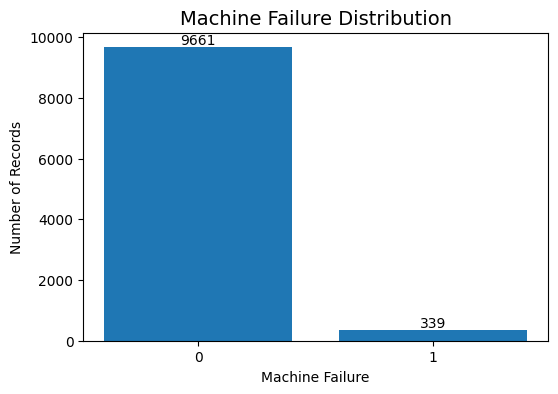

In [6]:
import matplotlib.pyplot as plt

failure_counts = df["Machine failure"].value_counts()

plt.figure(figsize=(6,4))

bars = plt.bar(
    failure_counts.index.astype(str),
    failure_counts.values
)

plt.title("Machine Failure Distribution", fontsize=14)
plt.xlabel("Machine Failure")
plt.ylabel("Number of Records")

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.savefig("../plots/failure_distribution.png")
plt.show()

The majority of machines are in the non-failure category (0), while only a small number belong to the failure category (1). This indicates that machine failures are relatively rare events in the dataset.

## Air Temperature Distribution

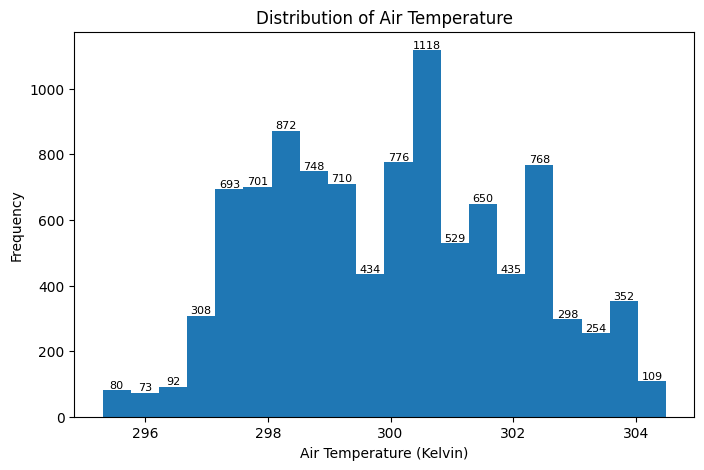

In [7]:
import matplotlib.pyplot as plt
import os

os.makedirs("../plots", exist_ok=True)

plt.figure(figsize=(8,5))

counts, bins, patches = plt.hist(
    df["Air temperature [K]"],
    bins=20
)

plt.title("Distribution of Air Temperature")
plt.xlabel("Air Temperature (Kelvin)")
plt.ylabel("Frequency")

# Add count labels on bars
for count, patch in zip(counts, patches):
    plt.text(
        patch.get_x() + patch.get_width()/2,
        count,
        int(count),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.savefig("../plots/air_temperature_distribution.png")
plt.show()


- The air temperature values range approximately from 295 K to 304 K.
- Most observations are concentrated between 298 K and 303 K.
- The highest frequency occurs around 300–301 K, indicating that machines generally operate under stable ambient temperature conditions.
- The distribution appears reasonably balanced without extreme outliers.
- Since temperature affects machine performance and failure behavior, this feature may be useful for predictive maintenance modeling.

## Process Temperature Distribution

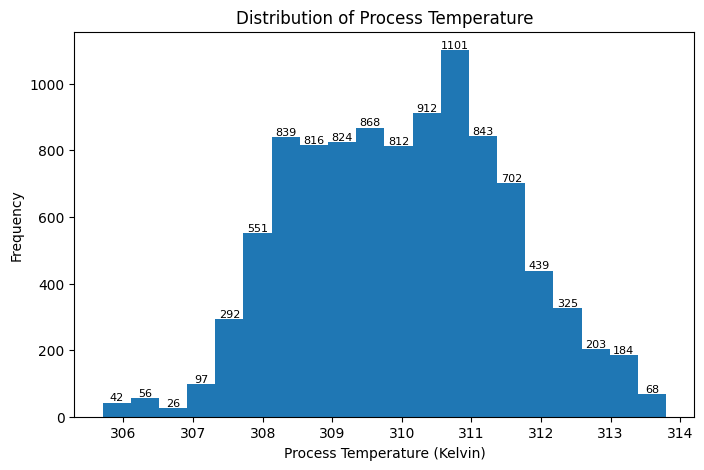

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

counts, bins, patches = plt.hist(
    df["Process temperature [K]"],
    bins=20
)

plt.title("Distribution of Process Temperature")
plt.xlabel("Process Temperature (Kelvin)")
plt.ylabel("Frequency")

for count, patch in zip(counts, patches):
    plt.text(
        patch.get_x() + patch.get_width()/2,
        count,
        int(count),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.savefig("../plots/process_temperature_distribution.png")
plt.show()


- Process temperature values are concentrated within a narrow operating range.
- Most observations lie around the central temperature values.
- No extreme outliers are visible in the distribution.
- Process temperature may influence machine performance and failure behavior.

## Rotational Speed Distribution

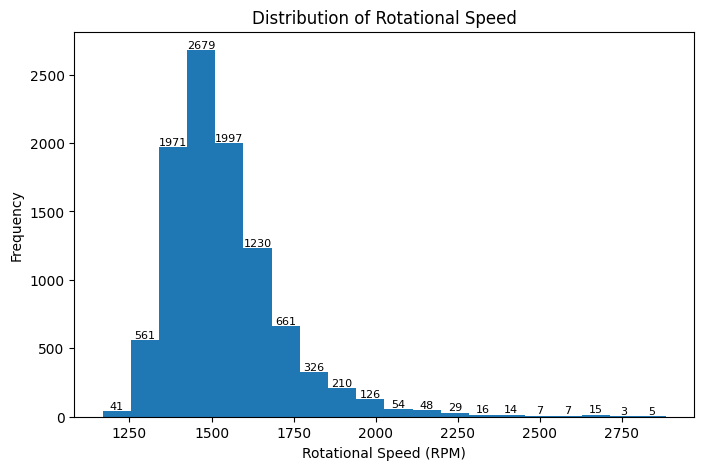

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

counts, bins, patches = plt.hist(
    df["Rotational speed [rpm]"],
    bins=20
)

plt.title("Distribution of Rotational Speed")
plt.xlabel("Rotational Speed (RPM)")
plt.ylabel("Frequency")

for count, patch in zip(counts, patches):
    plt.text(
        patch.get_x() + patch.get_width()/2,
        count,
        int(count),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.savefig("../plots/rotational_speed_distribution.png")
plt.show()


- Rotational speed values are distributed across the operating range.
- Most machines operate around the average RPM levels.
- Very high and very low RPM values occur less frequently.
- Rotational speed is an important indicator of machine operating conditions.

## Torque Distribution

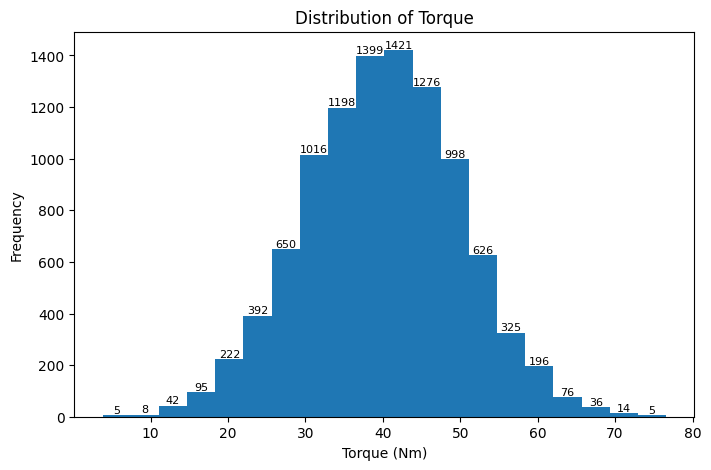

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

counts, bins, patches = plt.hist(
    df["Torque [Nm]"],
    bins=20
)

plt.title("Distribution of Torque")
plt.xlabel("Torque (Nm)")
plt.ylabel("Frequency")

for count, patch in zip(counts, patches):
    plt.text(
        patch.get_x() + patch.get_width()/2,
        count,
        int(count),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.savefig("../plots/torque_distribution.png")
plt.show()


- Torque values are centered around normal operating levels.
- Extremely high torque values occur less frequently.
- Variations in torque can indicate changes in machine load.
- Torque is a useful feature for predictive maintenance analysis.

## Tool Wear Distribution

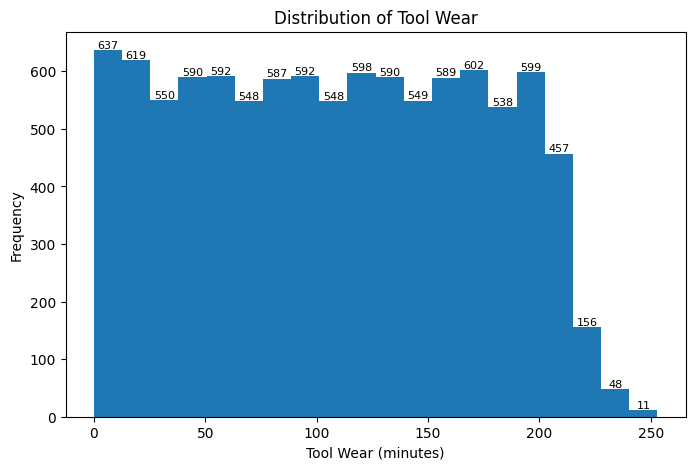

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

counts, bins, patches = plt.hist(
    df["Tool wear [min]"],
    bins=20
)

plt.title("Distribution of Tool Wear")
plt.xlabel("Tool Wear (minutes)")
plt.ylabel("Frequency")

for count, patch in zip(counts, patches):
    plt.text(
        patch.get_x() + patch.get_width()/2,
        count,
        int(count),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.savefig("../plots/tool_wear_distribution.png")
plt.show()


- Tool wear values are spread across different usage durations.
- Both new and heavily used tools are present in the dataset.
- Higher tool wear may contribute to machine failures.
- Tool wear is an important maintenance-related feature.

### Correlation Heatmap

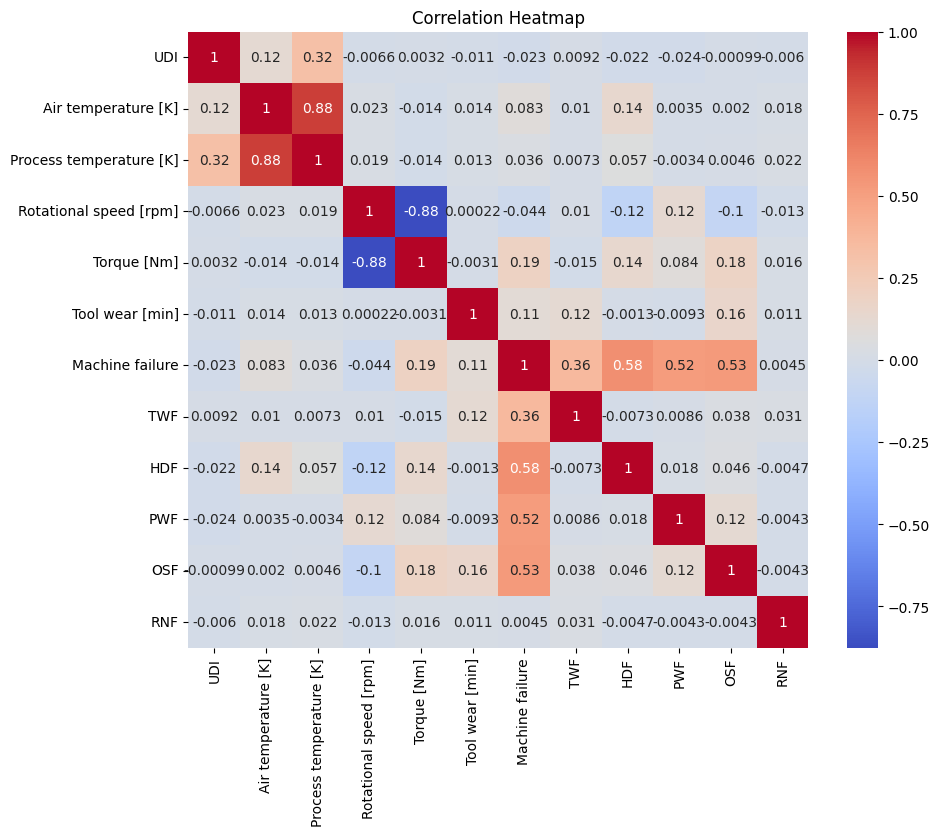

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("../plots/correlation_heatmap.png")
plt.show()

# Week 2 - Track 2 (EDA & Visualization)

## Objective

To analyze the engineered IoT-weather dataset containing machine telemetry and contextual environmental features, and provide visual evidence supporting the usefulness of contextual information in predictive maintenance.

---

## Task 1: Explore the Engineered Dataset

### Purpose

Understand the structure of the engineered IoT-weather dataset after contextual data fusion and rolling feature generation.

### Deliverables

* Dataset shape
* Feature list
* Data types inspection
* Missing value analysis

---

## Task 2: Analyze External Context Features

### Purpose

Study the distributions of engineered environmental features derived from weather data.

### Features

#### Engineered Temperature Features

* avg_temp_c_roll_mean
* avg_temp_c_roll_std
* avg_temp_c_roll_var

#### Engineered Atmospheric Features

* precipitation_mm_roll_mean
* precipitation_mm_roll_std
* precipitation_mm_roll_var
* avg_sea_level_pres_hpa_roll_mean
* avg_sea_level_pres_hpa_roll_std
* avg_sea_level_pres_hpa_roll_var

### Deliverables

* Distribution plots
* Summary observations
* Saved visualizations in plots/week2/

---

## Task 3: Analyze Machine Failure Distribution

### Purpose

Determine the percentage of failure and non-failure records and assess class imbalance.

### Deliverables

* Failure distribution bar chart
* Class imbalance percentages
* Observations

---

## Task 4: Generate Engineered Sensor Correlation Heatmap

### Purpose

Understand relationships among engineered machine telemetry features.

### Features

* Air temperature [K]_roll_mean
* Process temperature [K]_roll_mean
* Rotational speed [rpm]_roll_mean
* Torque [Nm]_roll_mean
* Tool wear [min]_roll_mean

### Deliverables

* Correlation heatmap
* Correlation observations

---

## Task 5: Generate Sensor–Weather Correlation Heatmap

### Purpose

Investigate relationships between machine telemetry and contextual environmental variables.

### Features

* Torque [Nm]_roll_mean
* Tool wear [min]_roll_mean
* avg_temp_c_roll_mean
* precipitation_mm_roll_mean
* avg_sea_level_pres_hpa_roll_mean

### Deliverables

* Combined correlation heatmap
* Weather impact observations

---

## Task 6: Analyze Failure Modes

### Purpose

Examine the distribution of different machine failure categories.

### Features

* TWF
* HDF
* PWF
* OSF
* RNF

### Deliverables

* Failure mode distribution chart
* Failure category observations

---

## Task 7: Tool Wear Lifecycle Analysis

### Purpose

Visualize degradation patterns and operational wear trends using engineered tool wear features.

### Features

* Tool wear [min]_roll_mean

### Deliverables

* Tool wear lifecycle chart
* Degradation observations

---

## Task 8: Week 2 Summary and Findings

### Purpose

Summarize key insights obtained from contextual feature exploration and visualization.

### Deliverables

* Summary of findings
* Correlation insights
* Evidence supporting contextual feature engineering


# Contextual Data Analysis


## Dataset Exploration

In [2]:
import pandas as pd

df = pd.read_csv("../engineered_iot_weather_dataset (1).csv")

print(df.shape)
print(df.columns.tolist())

df.head()

(9996, 40)
['UDI', 'Product ID', 'Type', 'date', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Air temperature [K]_roll_mean', 'Air temperature [K]_roll_std', 'Air temperature [K]_roll_var', 'Process temperature [K]_roll_mean', 'Process temperature [K]_roll_std', 'Process temperature [K]_roll_var', 'Rotational speed [rpm]_roll_mean', 'Rotational speed [rpm]_roll_std', 'Rotational speed [rpm]_roll_var', 'Torque [Nm]_roll_mean', 'Torque [Nm]_roll_std', 'Torque [Nm]_roll_var', 'Tool wear [min]_roll_mean', 'Tool wear [min]_roll_std', 'Tool wear [min]_roll_var', 'avg_temp_c_roll_mean', 'avg_temp_c_roll_std', 'avg_temp_c_roll_var', 'min_temp_c_roll_mean', 'min_temp_c_roll_std', 'min_temp_c_roll_var', 'max_temp_c_roll_mean', 'max_temp_c_roll_std', 'max_temp_c_roll_var', 'precipitation_mm_roll_mean', 'precipitation_mm_roll_std', 'precipitation_mm_roll_var', 'avg_sea_level_pres_hpa_roll_mean', 'avg_sea_level_pres_hpa_roll_std', 'avg_sea_level_pres_hpa_roll_var']


,UDI,Product ID,Type,date,Machine failure,TWF,HDF,PWF,OSF,RNF,...,min_temp_c_roll_var,max_temp_c_roll_mean,max_temp_c_roll_std,max_temp_c_roll_var,precipitation_mm_roll_mean,precipitation_mm_roll_std,precipitation_mm_roll_var,avg_sea_level_pres_hpa_roll_mean,avg_sea_level_pres_hpa_roll_std,avg_sea_level_pres_hpa_roll_var
0,5,L47184,L,2020-01-01,0,0,0,0,0,0,...,0.0,30.3,0.0,0.0,27.9,0.0,0.0,1014.4,0.0,0.0
1,6,M14865,M,2020-01-01,0,0,0,0,0,0,...,0.0,30.3,0.0,0.0,27.9,0.0,0.0,1014.4,0.0,0.0
2,7,L47186,L,2020-01-01,0,0,0,0,0,0,...,0.0,30.3,0.0,0.0,27.9,0.0,0.0,1014.4,0.0,0.0
3,8,L47187,L,2020-01-01,0,0,0,0,0,0,...,0.0,30.3,0.0,0.0,27.9,0.0,0.0,1014.4,0.0,0.0
4,9,M14868,M,2020-01-01,0,0,0,0,0,0,...,0.0,30.3,0.0,0.0,27.9,0.0,0.0,1014.4,0.0,0.0


In [4]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'date', 'Machine failure', 'TWF', 'HDF',
       'PWF', 'OSF', 'RNF', 'Air temperature [K]_roll_mean',
       'Air temperature [K]_roll_std', 'Air temperature [K]_roll_var',
       'Process temperature [K]_roll_mean', 'Process temperature [K]_roll_std',
       'Process temperature [K]_roll_var', 'Rotational speed [rpm]_roll_mean',
       'Rotational speed [rpm]_roll_std', 'Rotational speed [rpm]_roll_var',
       'Torque [Nm]_roll_mean', 'Torque [Nm]_roll_std', 'Torque [Nm]_roll_var',
       'Tool wear [min]_roll_mean', 'Tool wear [min]_roll_std',
       'Tool wear [min]_roll_var', 'avg_temp_c_roll_mean',
       'avg_temp_c_roll_std', 'avg_temp_c_roll_var', 'min_temp_c_roll_mean',
       'min_temp_c_roll_std', 'min_temp_c_roll_var', 'max_temp_c_roll_mean',
       'max_temp_c_roll_std', 'max_temp_c_roll_var',
       'precipitation_mm_roll_mean', 'precipitation_mm_roll_std',
       'precipitation_mm_roll_var', 'avg_sea_level_pres_hpa_roll_mean',
       

## External Context Feature Distributions


### 1.Engineered Temperature Features

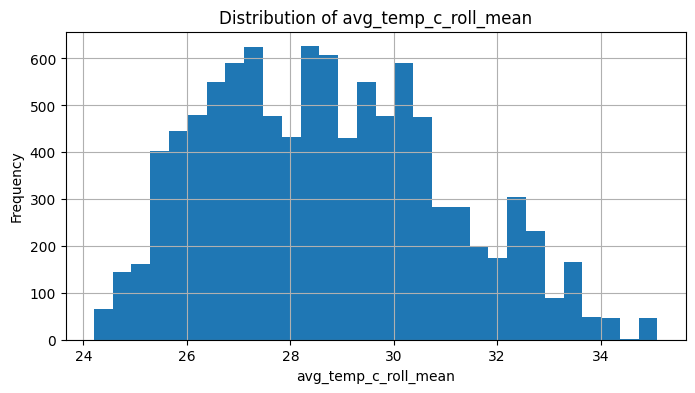

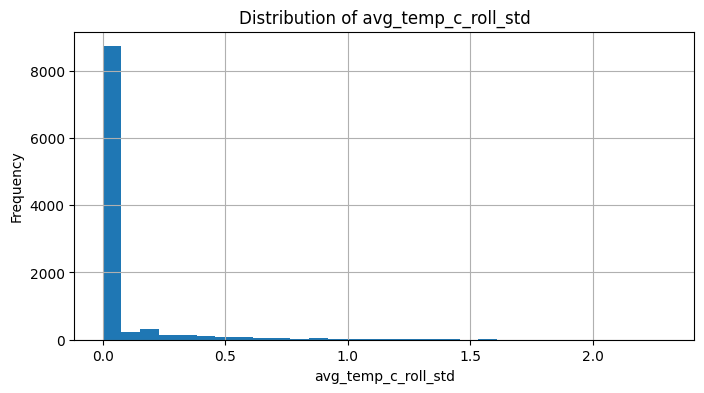

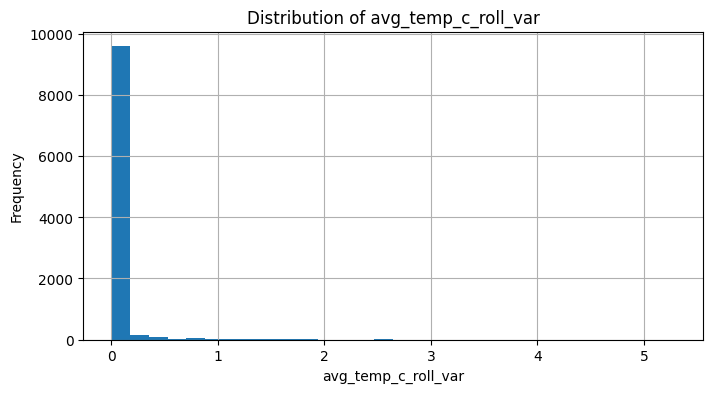

In [10]:
import matplotlib.pyplot as plt
import os

os.makedirs("../plots/week 2", exist_ok=True)

temp_features = [
    "avg_temp_c_roll_mean",
    "avg_temp_c_roll_std",
    "avg_temp_c_roll_var"
]

for col in temp_features:

    plt.figure(figsize=(8,4))

    df[col].hist(bins=30)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.savefig(
        f"../plots/week 2/{col}_distribution.png",
        bbox_inches="tight"
    )

    plt.show()

### Observation

Rolling statistical features were generated from external weather temperature measurements.

The rolling mean, standard deviation, and variance help capture temperature trends and variability that may influence machine operating conditions.

The engineered temperature features provide contextual environmental information that may contribute to predictive maintenance performance.

### 2.Engineered Atmospheric Features

Environmental conditions such as precipitation and atmospheric pressure were transformed into rolling statistical features.

These engineered variables help capture long-term weather behavior and fluctuations over time.

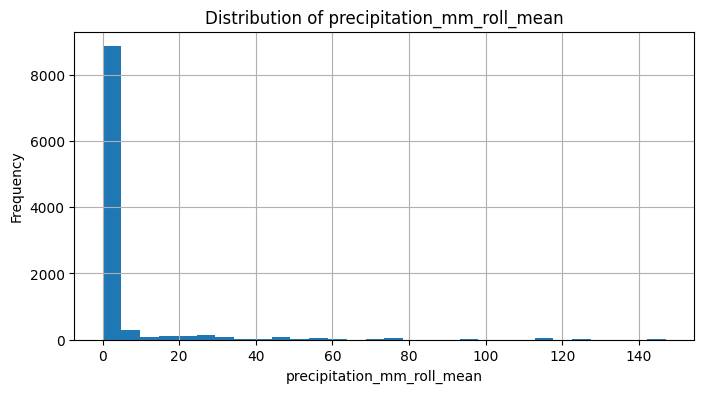

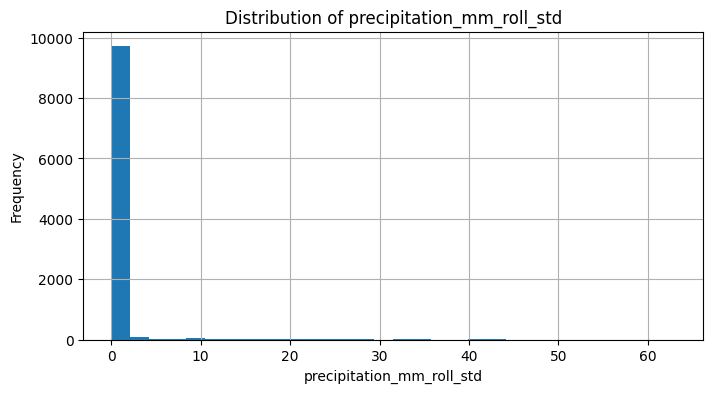

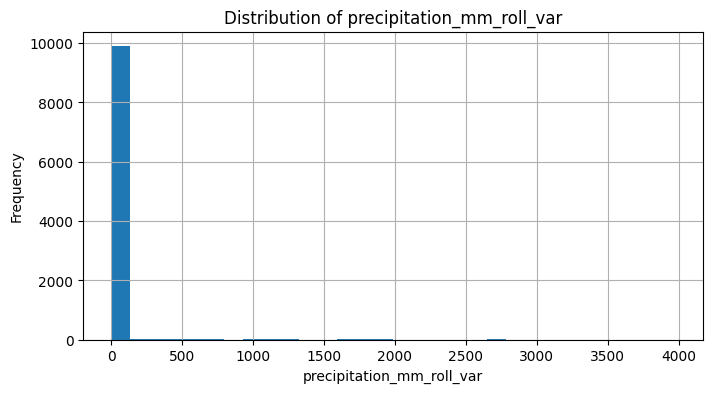

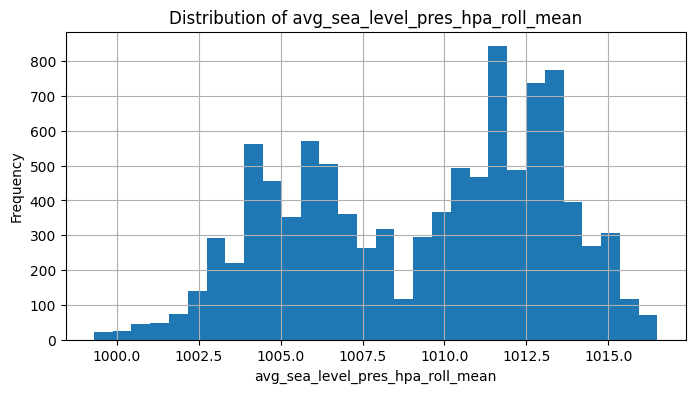

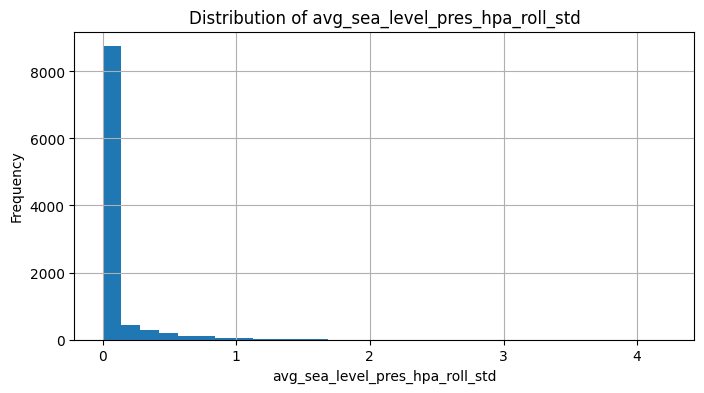

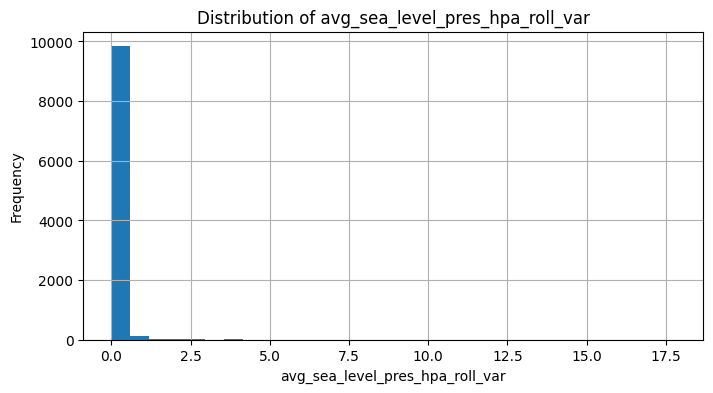

In [9]:
import matplotlib.pyplot as plt
import os

os.makedirs("../plots/week 2", exist_ok=True)
weather_features = [
    "precipitation_mm_roll_mean",
    "precipitation_mm_roll_std",
    "precipitation_mm_roll_var",
    "avg_sea_level_pres_hpa_roll_mean",
    "avg_sea_level_pres_hpa_roll_std",
    "avg_sea_level_pres_hpa_roll_var"
]

for col in weather_features:

    plt.figure(figsize=(8,4))

    df[col].hist(bins=30)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.savefig(
        f"../plots/week 2/{col}_distribution.png",
        bbox_inches="tight"
    )


    plt.show()

### Observation

The distributions of rolling precipitation and sea-level pressure features reveal the variability of environmental conditions within the dataset.

- The rolling mean features capture long-term weather trends.
- The rolling standard deviation features measure fluctuations and instability in weather conditions.
- The rolling variance features highlight periods of higher environmental variability.
- Most observations appear concentrated around typical operating weather conditions, while a smaller number of observations represent more extreme environmental situations.

These engineered weather features provide valuable contextual information that may help predictive maintenance models better understand machine behavior under varying environmental conditions.